# 14 — ReSpeaker Calibration

**Goal**: measure and correct per-mic gain and phase offsets using a
cross-correlation approach on a reference recording.

Steps:
1. Record a reference clip (boresight source — laptop speaker playing 1 kHz tone)
2. Estimate per-mic delay via cross-correlation with mic 0
3. Estimate per-mic gain from RMS ratios
4. Build calibration vector `e = g * exp(j*phi)` and apply to CSM
5. Quantify DoA error before vs after on a test recording
6. Save correction vector to `test/ReSpeaker/cal.npy`


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import scipy.io.wavfile as wavfile
from scipy.linalg import inv
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C          = 343.0
RADIUS     = 0.045
FS         = 16000
N_MICS     = 4
MIC_SLICE  = slice(2, 6)   # ch2-5 = Mic 0-3 raw
N_CHANNELS = 6
CAL_FREQ   = 1000.0        # calibration tone frequency (Hz)
CAL_SECS   = 5             # reference recording duration
TEST_SECS  = 3             # off-axis test recording duration

angles_deg = np.array([0.0, 90.0, 180.0, 270.0])
x = RADIUS * np.cos(np.radians(angles_deg))
y = RADIUS * np.sin(np.radians(angles_deg))

CAL_PATH = Path('../test/ReSpeaker/cal.npy')
REF_WAV  = Path('../test/ReSpeaker/cal_ref.wav')
TEST_WAV = Path('../test/ReSpeaker/cal_test.wav')


## 1 — Device Discovery


In [3]:
devs = sd.query_devices()
rs_idx = None
for i, d in enumerate(devs):
    if 'respeaker' in d['name'].lower() or 'xvf' in d['name'].lower():
        rs_idx = i
        rs_dev = d
        break

if rs_idx is None:
    raise RuntimeError('ReSpeaker not found — check USB connection')

print(f'Device [{rs_idx}]: {rs_dev["name"]}')
print(f'  {rs_dev["max_input_channels"]} ch  {rs_dev["default_samplerate"]:.0f} Hz  '
      f'{rs_dev["default_low_input_latency"]*1000:.1f} ms latency')


Device [12]: reSpeaker XVF3800 4-Mic Array: USB Audio (hw:4,0)
  6 ch  16000 Hz  23.9 ms latency


## 2 — Reference Recording

Play a 1 kHz tone from directly in front of the array (boresight, 0°) and
record 5 seconds.  A laptop speaker or phone at roughly 0.5–1 m works fine.

**Before running this cell**: position a tone source straight ahead of the
ReSpeaker (boresight) and start the tone.  The recording starts immediately.


In [4]:
print(f'Recording {CAL_SECS}s reference clip ... ', end='', flush=True)
ref_rec = sd.rec(int(CAL_SECS * FS), samplerate=FS,
                 channels=N_CHANNELS, dtype='float32', device=rs_idx)
sd.wait()
print('done')

REF_WAV.parent.mkdir(parents=True, exist_ok=True)
wavfile.write(REF_WAV, FS, (ref_rec * 32767).astype(np.int16))
print(f'Saved {REF_WAV}')

ref_mics = ref_rec[:, MIC_SLICE]   # shape (n_samp, 4)
print('RMS per mic:')
for i in range(N_MICS):
    print(f'  mic{i}: {np.sqrt(np.mean(ref_mics[:, i]**2)):.6f}')


Recording 5s reference clip ... done
Saved ../test/ReSpeaker/cal_ref.wav
RMS per mic:
  mic0: 0.023769
  mic1: 0.017207
  mic2: 0.021293
  mic3: 0.025830


## 3 — Delay & Gain Estimation

Cross-correlate each mic with mic 0 in the frequency domain to find the
fractional-sample delay.  At boresight the true delays are all zero, so any
measured delay is a hardware/cable offset to be corrected.


In [5]:
# Frequency-domain cross-correlation for sub-sample delay
def estimate_delay(ref_ch, mic_ch, fs):
    """Return delay in seconds: positive means mic_ch lags ref_ch."""
    n = len(ref_ch)
    F0 = np.fft.rfft(ref_ch, n=n)
    Fn = np.fft.rfft(mic_ch, n=n)
    xcorr = np.fft.irfft(np.conj(F0) * Fn, n=n)
    lag   = np.argmax(np.abs(xcorr))
    if lag > n // 2:
        lag -= n
    return lag / fs


delays = np.zeros(N_MICS)
for i in range(1, N_MICS):
    delays[i] = estimate_delay(ref_mics[:, 0], ref_mics[:, i], FS)

print('Estimated delays relative to mic 0 (should be ~0 at boresight):')
for i, d in enumerate(delays):
    print(f'  mic{i}: {d*1e6:+.1f} µs  ({d*FS:+.3f} samples)')

# Gain ratios
rms = np.array([np.sqrt(np.mean(ref_mics[:, i]**2)) for i in range(N_MICS)])
gains = rms / rms[0]
print('\nGain ratios (relative to mic 0):')
for i, g in enumerate(gains):
    print(f'  mic{i}: {g:.4f}  ({20*np.log10(g):+.2f} dB)')


Estimated delays relative to mic 0 (should be ~0 at boresight):
  mic0: +0.0 µs  (+0.000 samples)
  mic1: +0.0 µs  (+0.000 samples)
  mic2: +0.0 µs  (+0.000 samples)
  mic3: +0.0 µs  (+0.000 samples)

Gain ratios (relative to mic 0):
  mic0: 1.0000  (+0.00 dB)
  mic1: 0.7239  (-2.81 dB)
  mic2: 0.8958  (-0.96 dB)
  mic3: 1.0867  (+0.72 dB)


## 4 — Calibration Vector

The calibration vector `e` encodes the gain and phase offset of each mic
relative to mic 0.  Applying `R_cal = outer(1/e, conj(1/e)) * R_uncal`
removes the offsets from the cross-spectral matrix before beamforming.


In [6]:
# Phase at calibration frequency
phi = 2 * np.pi * CAL_FREQ * delays   # radians
e   = gains * np.exp(1j * phi)         # complex calibration vector, shape (N_MICS,)

print('Calibration vector e = g * exp(j*phi):')
for i in range(N_MICS):
    print(f'  mic{i}: |e|={np.abs(e[i]):.4f}  '
          f'phi={np.degrees(np.angle(e[i])):+.2f}°')


def apply_cal(R, e):
    """Apply calibration: R_cal = outer(1/e, conj(1/e)) * R"""
    c = 1.0 / e
    return np.outer(c, c.conj()) * R


CAL_PATH.parent.mkdir(parents=True, exist_ok=True)
np.save(CAL_PATH, e)
print(f'\nSaved calibration vector to {CAL_PATH}')


Calibration vector e = g * exp(j*phi):
  mic0: |e|=1.0000  phi=+0.00°
  mic1: |e|=0.7239  phi=+0.00°
  mic2: |e|=0.8958  phi=+0.00°
  mic3: |e|=1.0867  phi=+0.00°

Saved calibration vector to ../test/ReSpeaker/cal.npy


## 5 — Effect on Reference CSM

Apply the calibration to the reference recording's CSM.  After correction
the off-diagonal phases should be near zero (all mics in phase for a
boresight source).


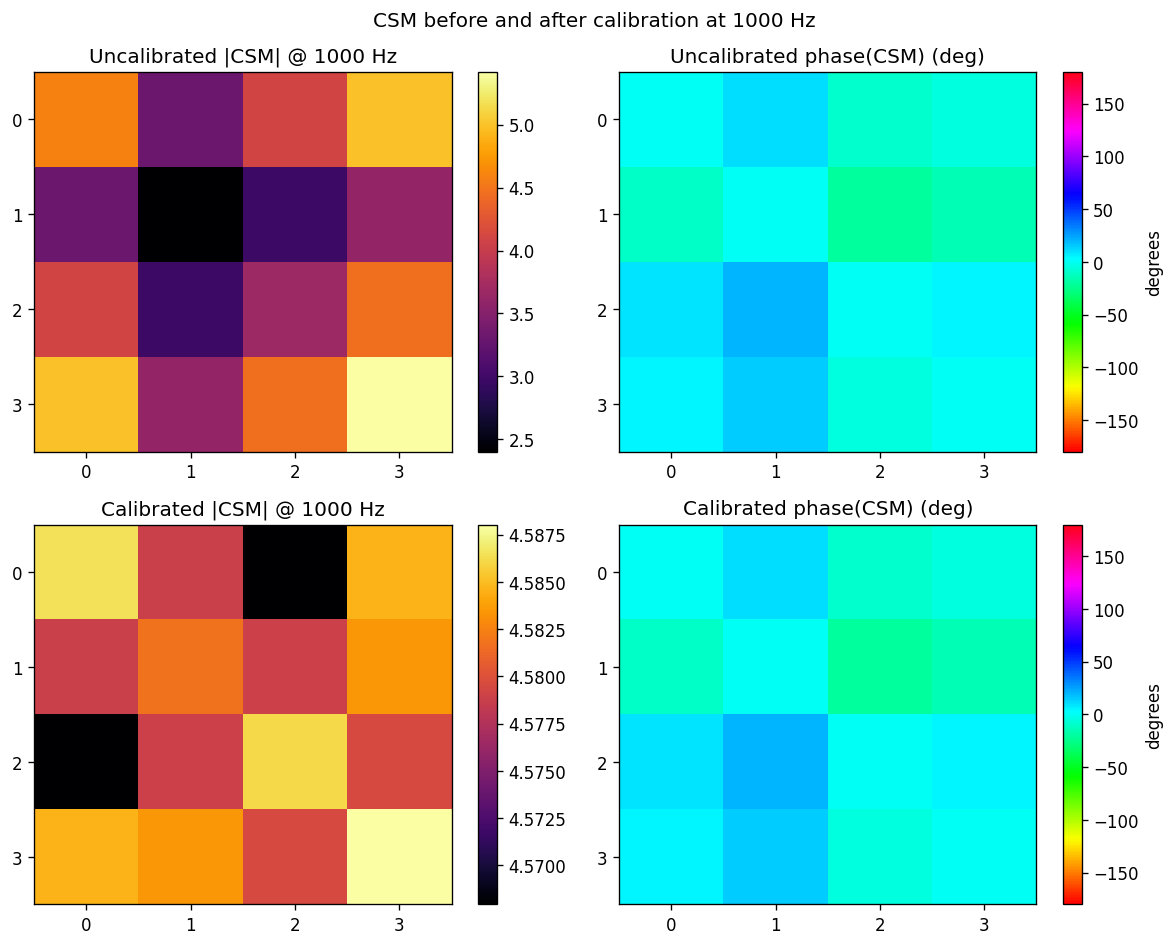

Off-diagonal phase BEFORE calibration (degrees):
  mic0-mic1: +10.4°
  mic0-mic2: -9.4°
  mic0-mic3: -4.8°
  mic1-mic2: -19.9°
  mic1-mic3: -15.2°
  mic2-mic3: +4.7°

Off-diagonal phase AFTER calibration (should be ~0°):
  mic0-mic1: +10.4°
  mic0-mic2: -9.4°
  mic0-mic3: -4.8°
  mic1-mic2: -19.9°
  mic1-mic3: -15.2°
  mic2-mic3: +4.7°


In [7]:
def compute_csm(audio, fs, freq, block_size=256, hop=128):
    n_samp, n_ch = audio.shape
    freqs   = np.fft.rfftfreq(block_size, 1/fs)
    f_idx   = np.argmin(np.abs(freqs - freq))
    f_actual = freqs[f_idx]
    R = np.zeros((n_ch, n_ch), dtype=complex)
    count = 0
    win = np.hanning(block_size)
    for start in range(0, n_samp - block_size, hop):
        block = audio[start:start + block_size] * win[:, np.newaxis]
        F = np.fft.rfft(block, axis=0)[f_idx]
        R    += np.outer(F, F.conj())
        count += 1
    return R / count, f_actual, count


R_ref, f_ref, _ = compute_csm(ref_mics, FS, CAL_FREQ)
R_cal_ref = apply_cal(R_ref, e)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (R, title) in enumerate([(R_ref, 'Uncalibrated'), (R_cal_ref, 'Calibrated')]):
    ax0 = axes[row, 0]
    ax1 = axes[row, 1]
    im0 = ax0.imshow(np.abs(R), cmap='inferno', aspect='auto')
    ax0.set_title(f'{title} |CSM| @ {f_ref:.0f} Hz')
    ax0.set_xticks(range(4)); ax0.set_yticks(range(4))
    plt.colorbar(im0, ax=ax0)
    im1 = ax1.imshow(np.degrees(np.angle(R)), cmap='hsv', aspect='auto',
                     vmin=-180, vmax=180)
    ax1.set_title(f'{title} phase(CSM) (deg)')
    ax1.set_xticks(range(4)); ax1.set_yticks(range(4))
    plt.colorbar(im1, ax=ax1, label='degrees')

plt.suptitle(f'CSM before and after calibration at {f_ref:.0f} Hz')
plt.tight_layout()
plt.savefig('respeaker_cal_csm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Off-diagonal phase BEFORE calibration (degrees):')
for i in range(N_MICS):
    for j in range(i+1, N_MICS):
        print(f'  mic{i}-mic{j}: {np.degrees(np.angle(R_ref[i,j])):+.1f}°')

print('\nOff-diagonal phase AFTER calibration (should be ~0°):')
for i in range(N_MICS):
    for j in range(i+1, N_MICS):
        print(f'  mic{i}-mic{j}: {np.degrees(np.angle(R_cal_ref[i,j])):+.1f}°')


## 6 — DoA Before vs After (Reference Recording)

Beamform the reference (boresight) recording before and after calibration.
Expected: calibrated peak should be closer to 0°.


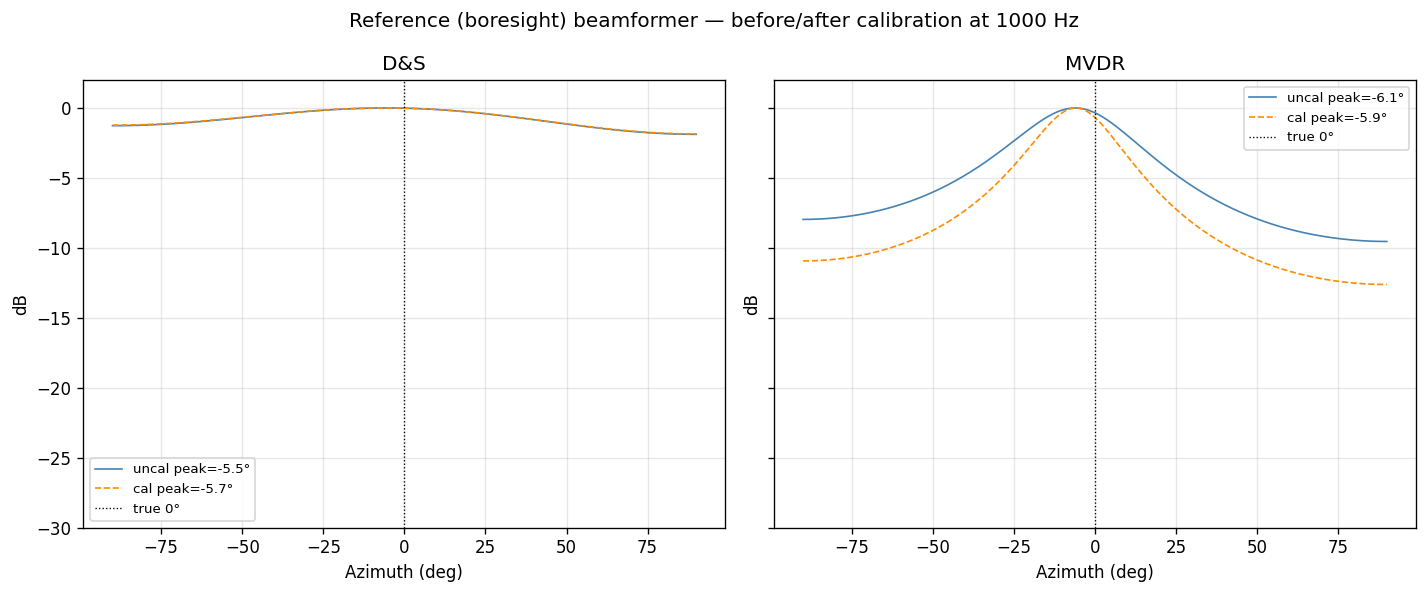

Reference recording DoA estimates (true: 0°):
  D&S  uncal: -5.5°   cal: -5.7°    improvement: -0.2°
  MVDR uncal: -6.1°   cal: -5.9°    improvement: +0.2°


In [8]:
def sm(x, y, az_grid, freq):
    u = np.sin(np.radians(az_grid))
    return np.exp(1j * 2 * np.pi * freq / C * np.outer(x, u)) / np.sqrt(len(x))


def beamform_ds(x, y, R, freq, az_grid):
    H = sm(x, y, az_grid, freq)
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(x, y, R, freq, az_grid, diag_load=0.01):
    N  = R.shape[0]
    Rl = R + diag_load * np.trace(R) / N * np.eye(N)
    Ri = inv(Rl)
    H  = sm(x, y, az_grid, freq)
    d  = np.real(np.sum(H.conj() * (Ri @ H), axis=0))
    return 1.0 / np.maximum(d, 1e-300)


def db_norm(p):
    return 10 * np.log10(np.maximum(p / p.max(), 1e-10))


az_grid = np.linspace(-90, 90, 1801)

P_ds_uncal  = beamform_ds(x, y, R_ref, f_ref, az_grid)
P_ds_cal    = beamform_ds(x, y, R_cal_ref, f_ref, az_grid)
P_mv_uncal  = beamform_mvdr(x, y, R_ref, f_ref, az_grid)
P_mv_cal    = beamform_mvdr(x, y, R_cal_ref, f_ref, az_grid)

az_ds_uncal = az_grid[np.argmax(P_ds_uncal)]
az_ds_cal   = az_grid[np.argmax(P_ds_cal)]
az_mv_uncal = az_grid[np.argmax(P_mv_uncal)]
az_mv_cal   = az_grid[np.argmax(P_mv_cal)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (label, P_u, P_c, az_u, az_c) in zip(axes, [
    ('D&S',  P_ds_uncal, P_ds_cal, az_ds_uncal, az_ds_cal),
    ('MVDR', P_mv_uncal, P_mv_cal, az_mv_uncal, az_mv_cal),
]):
    ax.plot(az_grid, db_norm(P_u), 'steelblue', linewidth=1, label=f'uncal peak={az_u:.1f}°')
    ax.plot(az_grid, db_norm(P_c), 'darkorange', linewidth=1, linestyle='--',
            label=f'cal peak={az_c:.1f}°')
    ax.axvline(0, color='k', linestyle=':', linewidth=0.8, label='true 0°')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('dB')
    ax.set_title(label)
    ax.set_ylim(-30, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Reference (boresight) beamformer — before/after calibration at {f_ref:.0f} Hz')
plt.tight_layout()
plt.savefig('respeaker_cal_doa_ref.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Reference recording DoA estimates (true: 0°):')
print(f'  D&S  uncal: {az_ds_uncal:+.1f}°   cal: {az_ds_cal:+.1f}°  '
      f'  improvement: {abs(az_ds_uncal)-abs(az_ds_cal):+.1f}°')
print(f'  MVDR uncal: {az_mv_uncal:+.1f}°   cal: {az_mv_cal:+.1f}°  '
      f'  improvement: {abs(az_mv_uncal)-abs(az_mv_cal):+.1f}°')


## 7 — Off-Axis Test Recording

Record a second clip with the source at a known off-axis angle to measure
calibration benefit in a more demanding scenario.  Aim for ~30–45° off
boresight for a clear test.

**Before running**: move the tone source to a clearly off-axis position
(estimate the angle visually to within ±5°).  Note the angle in the
`TRUE_ANGLE` variable below before executing.


In [ ]:
TRUE_ANGLE = 30.0   # <-- update this to match your test source angle

print(f'Recording {TEST_SECS}s off-axis clip (source at ~{TRUE_ANGLE}°) ... ',
      end='', flush=True)
test_rec = sd.rec(int(TEST_SECS * FS), samplerate=FS,
                  channels=N_CHANNELS, dtype='float32', device=rs_idx)
sd.wait()
print('done')

TEST_WAV.parent.mkdir(parents=True, exist_ok=True)
wavfile.write(TEST_WAV, FS, (test_rec * 32767).astype(np.int16))

test_mics = test_rec[:, MIC_SLICE]
R_test, f_test, _ = compute_csm(test_mics, FS, CAL_FREQ)
R_cal_test = apply_cal(R_test, e)

P_ds_u  = beamform_ds(x, y, R_test, f_test, az_grid)
P_ds_c  = beamform_ds(x, y, R_cal_test, f_test, az_grid)
P_mv_u  = beamform_mvdr(x, y, R_test, f_test, az_grid)
P_mv_c  = beamform_mvdr(x, y, R_cal_test, f_test, az_grid)

az_ds_u  = az_grid[np.argmax(P_ds_u)]
az_ds_c  = az_grid[np.argmax(P_ds_c)]
az_mv_u  = az_grid[np.argmax(P_mv_u)]
az_mv_c  = az_grid[np.argmax(P_mv_c)]

print(f'\nOff-axis test (true angle: {TRUE_ANGLE}°):')
print(f'  D&S  uncal: {az_ds_u:+.1f}°  error={abs(az_ds_u-TRUE_ANGLE):.1f}°')
print(f'  D&S  cal:   {az_ds_c:+.1f}°  error={abs(az_ds_c-TRUE_ANGLE):.1f}°')
print(f'  MVDR uncal: {az_mv_u:+.1f}°  error={abs(az_mv_u-TRUE_ANGLE):.1f}°')
print(f'  MVDR cal:   {az_mv_c:+.1f}°  error={abs(az_mv_c-TRUE_ANGLE):.1f}°')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (label, P_u, P_c, az_u, az_c) in zip(axes, [
    ('D&S',  P_ds_u, P_ds_c, az_ds_u, az_ds_c),
    ('MVDR', P_mv_u, P_mv_c, az_mv_u, az_mv_c),
]):
    ax.plot(az_grid, db_norm(P_u), 'steelblue', linewidth=1,
            label=f'uncal peak={az_u:.1f}°')
    ax.plot(az_grid, db_norm(P_c), 'darkorange', linewidth=1, linestyle='--',
            label=f'cal peak={az_c:.1f}°')
    ax.axvline(TRUE_ANGLE, color='k', linestyle=':', linewidth=0.8,
               label=f'true {TRUE_ANGLE}°')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('dB')
    ax.set_title(label)
    ax.set_ylim(-30, 2)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Off-axis test beamformer — before/after calibration at {f_test:.0f} Hz')
plt.tight_layout()
plt.savefig('respeaker_cal_doa_test.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

Key findings to document in PHASE2.md:
- Per-mic delays and gains
- CSM phase change after calibration
- DoA error before and after on boresight and off-axis sources
- Whether mic1 (lowest power in nb13) shows a hardware defect or normal variation


In [ ]:
print('=== nb14 Summary ===')
print(f'Calibration frequency: {CAL_FREQ:.0f} Hz')
print(f'\nPer-mic delays (relative to mic0):')
for i, d in enumerate(delays):
    print(f'  mic{i}: {d*1e6:+.1f} µs')
print(f'\nPer-mic gains (relative to mic0):')
for i, g in enumerate(gains):
    print(f'  mic{i}: {g:.4f} ({20*np.log10(g):+.2f} dB)')
print(f'\nCalibration saved to: {CAL_PATH}')
print(f'\nDoA improvement on reference (boresight, true=0°):')
print(f'  D&S:  {abs(az_ds_uncal):.1f}° → {abs(az_ds_cal):.1f}°')
print(f'  MVDR: {abs(az_mv_uncal):.1f}° → {abs(az_mv_cal):.1f}°')
